In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import StandardScaler, PolynomialFeatures 
from sklearn.metrics import mean_squared_error 

import tensorflow as tf

np.set_printoptions(precision=2)
plt.style.use("seaborn-v0_8")

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

In [3]:
data = np.loadtxt("data_w3_ex1.csv", delimiter=",")

In [4]:
x = data[:, 0]
y = data[:, 1]

x = np.expand_dims(x, axis=1)
y = np.expand_dims(y, axis=1)

print(x.shape)
print(y.shape)

(50, 1)
(50, 1)


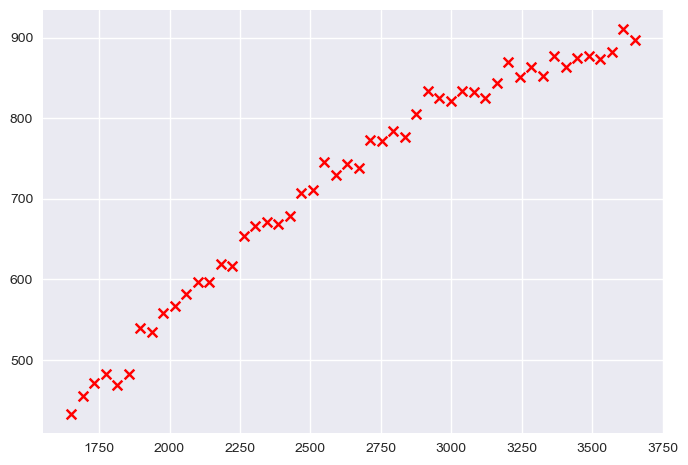

In [5]:
plt.scatter(x, y, marker="x", c="r")
plt.show()

In [6]:
x_train, x_, y_train, y_ = train_test_split(x, y, test_size=0.4, random_state=1)
x_cv, x_test, y_cv, y_test = train_test_split(x_, y_, test_size=0.5, random_state=1)

del x_, y_ 

print(x_train.shape)
print(x_cv.shape)
print(x_test.shape)

(30, 1)
(10, 1)
(10, 1)


In [7]:
scaler_linear = StandardScaler()
x_train_scaled = scaler_linear.fit_transform(x_train)

print(f"x_train mean: {scaler_linear.mean_.squeeze():.2f}")
print(f"x_train std: {scaler_linear.scale_.squeeze():.2f}")

x_cv_scaled = scaler_linear.transform(x_cv)
x_test_scaled = scaler_linear.transform(x_test)

x_train mean: 2504.06
x_train std: 574.85


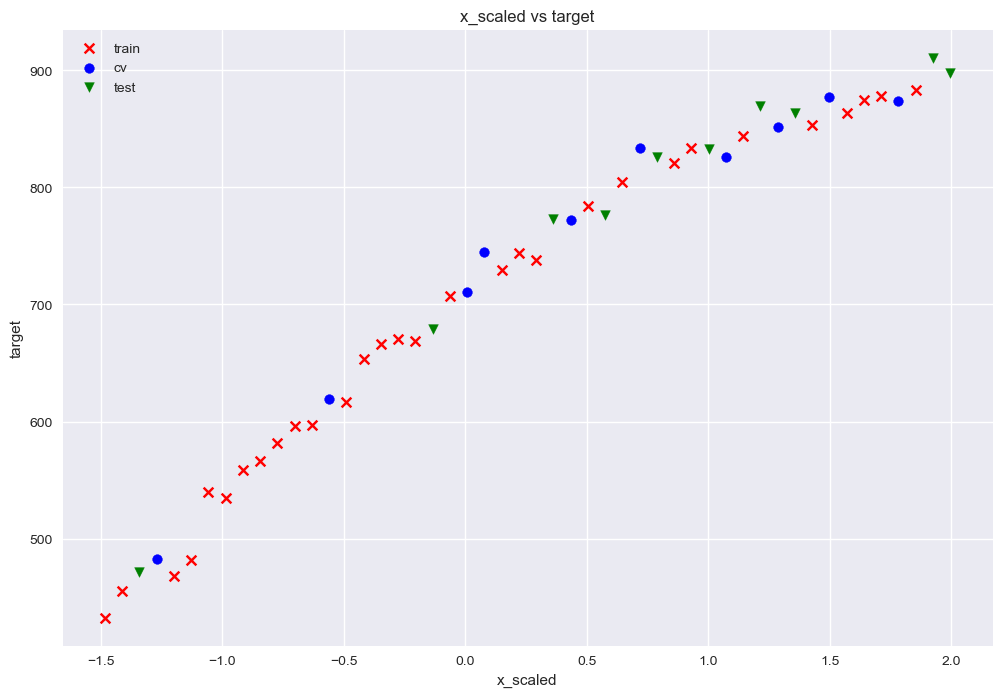

In [8]:
fig, ax = plt.subplots(1,1,figsize=(12,8))
ax.scatter(x_train_scaled, y_train, marker="x", c="r", label="train")
ax.scatter(x_cv_scaled, y_cv, marker="o", c="b", label="cv")
ax.scatter(x_test_scaled, y_test, marker="v", c="g", label="test")
ax.set_title("x_scaled vs target")
ax.set_xlabel("x_scaled")
ax.set_ylabel("target")
plt.legend()
plt.show()


In [9]:
linear_model = LinearRegression()
training = linear_model.fit(x_train_scaled, y_train)

In [10]:
yhat = linear_model.predict(x_train_scaled)
train_mse = mean_squared_error(y_train, yhat)/2
print(f"train_mse: {train_mse:.2f}")

yhat = linear_model.predict(x_cv_scaled)
cv_mse = mean_squared_error(y_cv, yhat)/2
print(f"cv_mse: {cv_mse:.2f}")


train_mse: 406.19
cv_mse: 551.78


In [11]:
train_mses = []
cv_mses = []
models = []
polys = []
scalers = []

for degree in range(1, 11):

    poly = PolynomialFeatures(degree, include_bias=False)
    x_train_mapped = poly.fit_transform(x_train)
    polys.append(poly)

    scaler = StandardScaler()
    x_train_mapped_scaled = scaler.fit_transform(x_train_mapped)
    scalers.append(scaler)

    model = LinearRegression()
    training = model.fit(x_train_mapped_scaled, y_train)
    models.append(model)

    yhat = model.predict(x_train_mapped_scaled)
    train_mse = mean_squared_error(y_train, yhat)/2
    train_mses.append(train_mse)

    x_cv_mapped = poly.transform(x_cv)
    x_cv_mapped_scaled = scaler.transform(x_cv_mapped)
    yhat = model.predict(x_cv_mapped_scaled)
    cv_mse = mean_squared_error(y_cv, yhat)/2
    cv_mses.append(cv_mse)


In [12]:
idx = np.argmin(cv_mses)
print(f"the lowest cv error index (degree): {idx + 1}")

x_test_mapped = polys[idx].transform(x_test)
x_test_mapped_scaled = scalers[idx].transform(x_test_mapped)

yhat = models[idx].predict(x_test_mapped_scaled)
test_mse = mean_squared_error(y_test, yhat)/2

print(f"x_train mse: {train_mses[idx]:.2f}")
print(f"x_cv mse: {cv_mses[idx]:.2f}")
print(f"x_test mse: {test_mse:.2f}")

the lowest cv error index (degree): 4
x_train mse: 47.15
x_cv mse: 79.43
x_test mse: 104.63


In [19]:
# neural network
degree = 1
poly = PolynomialFeatures(degree, include_bias=False)
x_train_mapped = poly.fit_transform(x_train)
x_cv_mapped = poly.transform(x_cv)
x_test_mapped = poly.transform(x_test)

In [20]:
scaler = StandardScaler()
x_train_mapped_scaled = scaler.fit_transform(x_train_mapped)
x_cv_mapped_scaled = scaler.transform(x_cv_mapped)
x_test_mapped_scaled = scaler.transform(x_test_mapped)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam

In [22]:
model1 = Sequential([
    Dense(25, "relu"),
    Dense(15, "relu"),
    Dense(1)
])
model2 = Sequential([
    Dense(20, "relu"),
    Dense(12, "relu"),
    Dense(12, "relu"),
    Dense(20, "relu"),
    Dense(1)
])
model3 = Sequential([
    Dense(32, "relu"),
    Dense(16, "relu"),
    Dense(12, "relu"),
    Dense(8, "relu"),
    Dense(4, "relu"),
    Dense(1)
])

In [25]:
nn_train_mse = []
nn_cv_mse = []

for model in [model1, model2, model3]:

    model.compile(loss="mse", optimizer=Adam(learning_rate=0.01))
    model.fit(x_train_mapped_scaled, y_train, epochs=10)

    yhat = model.predict(x_train_mapped_scaled)
    train_mse = mean_squared_error(y_train, yhat)/2
    nn_train_mse.append(train_mse)

    yhat = model.predict(x_cv_mapped_scaled)
    cv_mse = mean_squared_error(y_cv, yhat)/2
    nn_cv_mse.append(cv_mse)
    print("done!")
    
print(np.argmin(nn_cv_mse)+1)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step - loss: 481461.8125
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 481078.8438
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 480665.2188
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 480218.6250
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 479736.5938
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 479216.5625
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 478656.3438
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 478053.1562
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 477404.4375
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 476707.3438
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
done!
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 555ms/step - loss: 483481.3750
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 483394.3750
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 483289.4688
Epoch 4/10
1/1 ━━━

In [27]:
# binary classification

data = np.loadtxt("data_w3_ex2.csv",delimiter=",")

x_bc = data[:,:-1]
y_bc = data[:,-1]

y_bc = np.expand_dims(y_bc, axis=1)

print(x_bc.shape)
print(y_bc.shape)

(200, 2)
(200, 1)


In [28]:
x_bc_train, x_bc_, y_bc_train, y_bc_ = train_test_split(x_bc, y_bc, test_size=0.4, random_state=1)
x_bc_cv, x_bc_test, y_bc_cv, y_bc_test = train_test_split(x_bc_, y_bc_, test_size=0.5, random_state=1)

print(x_bc_train.shape)
print(x_bc_cv.shape)
print(x_bc_test.shape)

(120, 2)
(40, 2)
(40, 2)


In [29]:
scaler = StandardScaler()
x_bc_train_scaled = scaler.fit_transform(x_bc_train)
x_bc_cv_scaled = scaler.transform(x_bc_cv)
x_bc_test_scaled = scaler.transform(x_bc_test)

In [30]:
model1 = Sequential([
    Dense(25, "relu"),
    Dense(15, "relu"),
    Dense(1)
])
model2 = Sequential([
    Dense(20, "relu"),
    Dense(12, "relu"),
    Dense(12, "relu"),
    Dense(20, "relu"),
    Dense(1)
])
model3 = Sequential([
    Dense(32, "relu"),
    Dense(16, "relu"),
    Dense(12, "relu"),
    Dense(8, "relu"),
    Dense(4, "relu"),
    Dense(1)
])


In [31]:
nn_bc_train_mse = []
nn_bc_cv_mse = []

for model in [model1, model2, model3]:

    model.compile(loss=BinaryCrossentropy(from_logits=True), optimizer=Adam(learning_rate=0.01))
    model.fit(x_bc_train_scaled, y_bc_train, epochs=10)

    yhat = model.predict(x_bc_train_scaled)
    yhat = tf.math.sigmoid(yhat)
    yhat = np.where(yhat>=0.5, 1, 0)
    train_mse = np.mean(yhat != y_bc_train)
    nn_bc_train_mse.append(train_mse)

    yhat = model.predict(x_bc_cv_scaled)
    yhat = tf.math.sigmoid(yhat)
    yhat = np.where(yhat>=0.5, 1, 0)
    cv_mse = np.mean(yhat != y_bc_cv)
    nn_bc_cv_mse.append(cv_mse)
    print("done!")
    
print(np.argmin(nn_bc_cv_mse)+1)

Epoch 1/10


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7027  
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5811 
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4912 
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4055 
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step - loss: 0.3411
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3039 
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2882 
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2874 
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2880 
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2845
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
done!
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6842  
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6248 
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5386 
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4159 
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━